# Describing and Comparing

In this session, we will cover functions for describing your data using descriptive statistics and univariate (one variable) plots. We will also start making simple comparisons that aid in description by illustrating the dimensionality in the data or potential causal relationships. 

In [68]:
pacman::p_load(
          tidyverse, 
          modelsummary,
          gt,
          marginaleffects
          )

Read in your .csv data downloaded from IPUMS. 

In [69]:
# requires download of ASEC data from IPUMS 
asec25nj <- read_csv("./asec25nj.csv")

Rows: 2515 Columns: 17
── Column specification ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
dbl (17): YEAR, SERIAL, MONTH, CPSID, ASECFLAG, ASECWTH, STATEFIP, COUNTY, PERNUM, CPSIDP, CPSIDV, ASECWT, AGE, SEX, EMPSTAT, LABFORC...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Here we use `mutate()` with `case_when` to recode employment status and eduction variables from the ASEC into a binary (0,1) variable describing those who are unemployed and a variable recording educational attainment. 

In [70]:
asec25nj.rec <- asec25nj |> 
  mutate(
    unemployed = case_when(
      EMPSTAT == 10 | EMPSTAT == 12 ~ 0,
      EMPSTAT >= 20 & EMPSTAT <= 22 ~ 1,
      TRUE ~ NA
    ),
    ed.att = case_when(
      EDUC >= 2 & EDUC <72 ~ 1,
      EDUC == 72 | EDUC == 73 ~ 2, 
      EDUC >= 80 & EDUC <= 110 ~ 3,
      EDUC == 120 | EDUC == 121 | EDUC == 122 ~ 3,
      EDUC == 111 ~ 4,
      EDUC == 123 | EDUC == 124 | EDUC == 125 ~ 5,
      TRUE ~ NA
    ),
    age.cat = cut(AGE, 
      breaks = c(0, 18, 30, 45, 67, 100),
    )
  )

## Frequency tables

Frequency tables show the dispersion of your dataset across the values of a variable. Here, let's present the distribution of educational attainment. We'll incorporate survey weights to make our counts better representative of the state population. 

In [71]:
freq <- asec25nj.rec |>
  group_by(ed.att) |>        # group all of your data by values of ed.att
  summarize(                 # aggregates data to grouped level 
    Number = sum(ASECWT),    # sums values of our weighting variable
  ) |>
  mutate(                             
    Percent = 100* Number/sum(Number), # calculates percentage by taking count and dividing by total
  )

freq

# A tibble: 6 × 3
  ed.att   Number Percent
   <dbl>    <dbl>   <dbl>
1      1  759067.    8.12
2      2 1913713.   20.5 
3      3 1490165.   15.9 
4      4 2163307.   23.1 
5      5 1346320.   14.4 
6     NA 1680563.   18.0 

## Summary Statitics 

R has many built-in functions to calculate simple summary statistics, although not all work with survey weights (other packages are useful for extending your work with survey data). 

In [72]:
# calculate an average value
mean(asec25nj.rec$unemployed, na.rm = TRUE)
weighted.mean(asec25nj.rec$unemployed, na.rm = TRUE)
sd(asec25nj.rec$unemployed, na.rm = TRUE)

# using tidy syntax:

asec25nj.rec |>
  summarize(
    `Mean of Unemployed` = mean(unemployed, na.rm = TRUE),
    `Mean of Unemployed (Weighted)` = weighted.mean(unemployed, na.rm = TRUE),
    `SD of Unemployed` = sd(unemployed, na.rm = TRUE)
  )


# A tibble: 1 × 3
  `Mean of Unemployed` `Mean of Unemployed (Weighted)` `SD of Unemployed`
                 <dbl>                           <dbl>              <dbl>
1               0.0483                          0.0483              0.214

## Bar graphs

The data presented in our frequency table perhaps could be better displayed as a bar graph. `ggplot2` is an excellent, all-purpose graphing package that is bundled in the **{tidyverse}** suite. Graphs are built layer by layer. First, we describe the plot space using `ggplot()`, then represent our data using `geom_bar()`. 

Warning message:
Removed 466 rows containing non-finite outside the scale range (`stat_count()`). 


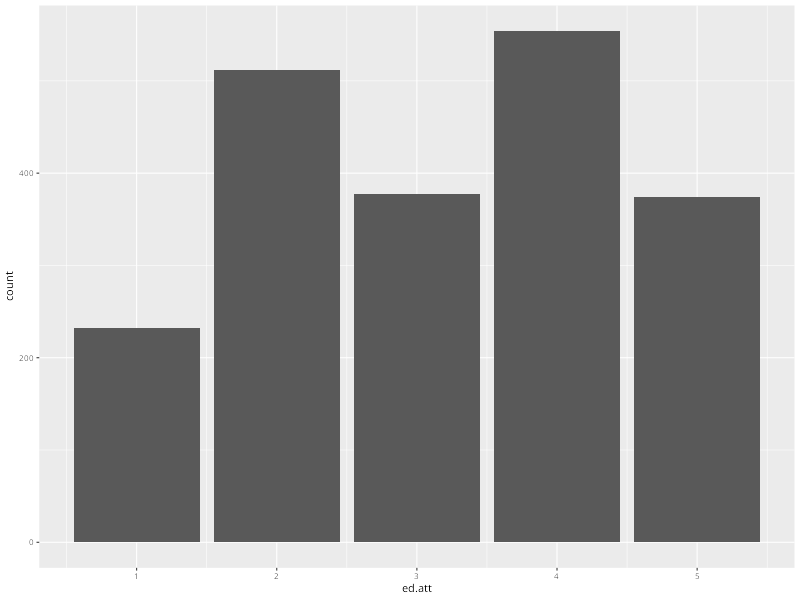

In [73]:
ggplot(
  data = asec25nj.rec,   # any attributes we include here will be passed on to the geoms below
  mapping = aes(
    x = ed.att,
    )
) +                      # graph layers linked by +
  geom_bar() 

Warning message:
Removed 466 rows containing non-finite outside the scale range (`stat_count()`). 


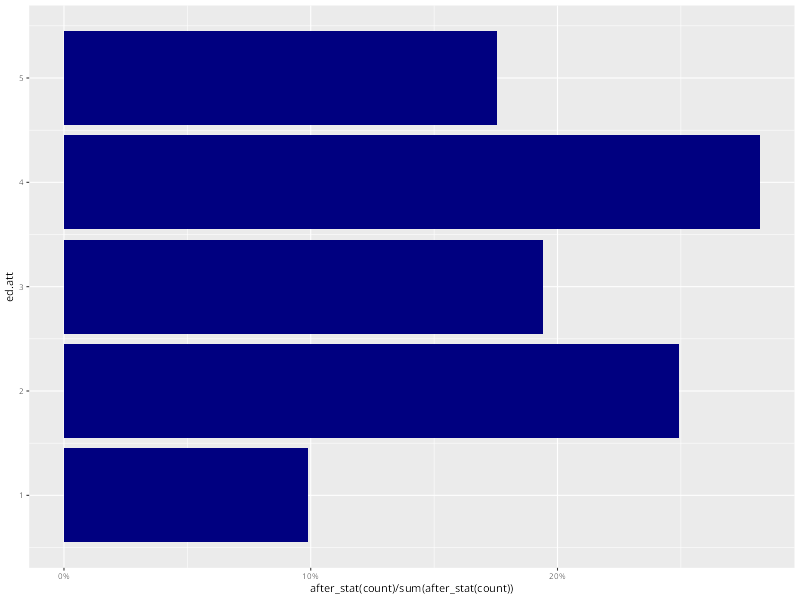

In [74]:
ggplot(
  data = asec25nj.rec,
  mapping = aes(x = ed.att, 
                y = after_stat(count)/sum(after_stat(count)),
              )
) +
  geom_bar(aes(weight = ASECWT), fill = "navy") +
  scale_y_continuous(labels = scales::percent) +
  coord_flip()

## Joint frequency tables

Now that we have presented our univariate data, let's work on making some simple comparisons. How does the unemployment rate change by educational attainment? We can make a *joint frequency table*, or crosstab, by present the values of unemployment by values of education.

Here are two methods. The first uses the `datasummary_crosstab` function from the **{modelsummary}** package, but does not incorporate weights. The second method is more tedious, but we use our weight variable as we generate our counts.

In [75]:
# from modelsummary package
datasummary_crosstab(
  formula = unemployed ~ ed.att,                  # syntax: rows ~ columns
  statistic = 1 ~ 1 + N + Percent("col"),         # calculates counts and percentages by column
  data = asec25nj.rec |>                          
    filter(!is.na(unemployed) & !is.na(ed.att)),  # filters out missing data ! means "not"
  )

asec25nj.rec |> 
  filter(!is.na(unemployed) & !is.na(ed.att)) |>
  group_by(unemployed, ed.att) |>                 # group by both variables
  summarize(count = sum(ASECWT)) |>
  ungroup() |>                                    # drop grouping
  group_by(ed.att) |>                             # regroup by predictor variable
  summarize(                                      # aggregate to predictor variable values
    N = count,
    Percent = 100 *(count / sum(count))
  ) |>
  mutate(Unemployed = row_number() - 1) |>        # generates 0,1 Unemployment codes
  pivot_longer(                                   # transposes data into additional rows
    cols = c("Percent", "N"),
    names_to = "Statistic",
    values_to = "value"
  ) |>
  pivot_wider(                                    # transposes data back into columns
    names_from = ed.att,
    values_from = value
  )


unemployed,,1,2,3,4,5,All
0,N,42,274,227,405,274,1222
,% col,84.0,94.2,95.8,96.4,95.8,95.2
1,N,8,17,10,15,12,62
,% col,16.0,5.8,4.2,3.6,4.2,4.8
All,N,50,291,237,420,286,1284
,% col,100.0,100.0,100.0,100.0,100.0,100.0


`summarise()` has grouped output by 'unemployed'. You can override using the `.groups` argument.
`summarise()` has grouped output by 'ed.att'. You can override using the `.groups` argument.


Warning message:
Returning more (or less) than 1 row per `summarise()` group was deprecated in dplyr 1.1.0.
ℹ Please use `reframe()` instead.
ℹ When switching from `summarise()` to `reframe()`, remember that `reframe()` always returns an ungrouped data frame and adjust
  accordingly.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was generated. 


# A tibble: 4 × 7
  Unemployed Statistic      `1`       `2`       `3`        `4`       `5`
       <dbl> <chr>        <dbl>     <dbl>     <dbl>      <dbl>     <dbl>
1          0 Percent       84.7     93.6      96.1       96.4      95.8 
2          0 N         125115.  992442.   874809.   1543306.   942924.  
3          1 Percent       15.3      6.44      3.89       3.62      4.20
4          1 N          22595.   68259.    35425.     58019.    41351.  

## Comparisons of Means 

An alternative to a joint frequency table is a mean comparison table. If that variable we're analyzing is measured at the continuous level (something we can count) or as a binary variable (0s and 1s), then we can present how the average values of that variable might change over categories of a predictor variable. Let's present the average of `unemployed` by educational attainment. 

In [76]:
asec25nj.rec |>
  group_by(ed.att) |>
  summarize(
    `Pct. Unemployed` = 100 * weighted.mean(unemployed, ASECWT, na.rm = TRUE)
  )

# A tibble: 6 × 2
  ed.att `Pct. Unemployed`
   <dbl>             <dbl>
1      1             15.3 
2      2              6.44
3      3              3.89
4      4              3.62
5      5              4.20
6     NA            NaN   

This time, let's group by two variables: education and sex, and store the table. We can then pass the table into **{gt}**, a useful table-making package, for fiddling with table formatting. 

In [77]:


tab.unemployed <- asec25nj.rec |>
  group_by(ed.att, SEX) |>
  mutate(
    ed.att = factor(ed.att, 
      levels = c(1,2,3,4,5),
      labels = c("<HS", "HS", "Some College", "BA", "More than BA")
    ),
    SEX = factor(SEX, 
      levels = c(1,2),
      labels = c("Male", "Female")
    )
  ) |>
  summarize(`Pct. Unemployed` = 100 * weighted.mean(unemployed, ASECWT, na.rm = TRUE)) |>
  pivot_wider(
    names_from = SEX,
    values_from = `Pct. Unemployed`
  ) |>
  ungroup()

out <- gt(tab.unemployed |> filter(!is.na(ed.att)),
          rowname_col = "ed.att") |>
       cols_label(
        Male = "Men",
        Female = "Women"
       ) |>
       fmt_number(
        columns = c("Male", "Female"),
        decimals = 1,
       ) |>
       cols_align(
        columns = c("Male", "Female"),
        align = "center"
       ) 
out

`summarise()` has grouped output by 'ed.att'. You can override using the `.groups` argument.


,Men,Women
<HS,13.8,17.1
HS,8.6,3.3
Some College,3.2,4.6
BA,4.7,2.6
More than BA,5.9,2.4


## Regression 

Regression is a statistical method used for prediction, forecasting, and causal inference. Without going into details beyond the scope of our workshop, regression presents another way to describe the relationship of some outcome (like unemployment) to a predictor (like education). The most common regression method is called Ordinary Least Squares, which fits a straight line between values of your predictor and outcome in such a way as to minimize the error between line and each value of the outcome. A second method, maximum likelihood estimation (MLE), relaxes the assumption of a straight line and allows for other types of relationships between outcome and predictors. One common approach is the logit, which explains the relationship between a binary outcome (0,1 data) and some predictor(s). 

Regression very useful for researchers because it allows them to incorporate multiple predictor variables easily. Below, let's model the relationship between unemployment and education, sex, and age. 

In [78]:

ols <- lm(unemployed ~ AGE + factor(ed.att) + factor(SEX), # here we treat educ and sex as factors
          data = asec25nj.rec)                             
summary(ols)                                               # shows model estimates

logit <- glm(unemployed ~ AGE + factor(ed.att) + factor(SEX), 
          family = binomial(link = "logit"),
          data = asec25nj.rec)
summary(logit)

# modelsummary will make table of estimates for sharing and display
modelsummary(
  list("Linear"= ols, "Logistic" = logit),
  estimate = "{estimate}{stars}",
  statistic = "({std.error})",
  coef_rename = c("AGE" = "Age",                         # rename coefficients for presentation
                  "factor(ed.att)2" = "High School",
                  "factor(ed.att)3" = "Some College",
                  "factor(ed.att)4" = "Bachelor's",
                  "factor(ed.att)5" = "Grad or Prof",
                  "factor(SEX)2" = "Women"
                )
)


,Linear,Logistic
(Intercept),0.169***,-1.468**
,(0.034),(0.520)
Age,-0.000,-0.001
,(0.000),(0.009)
High School,-0.102**,-1.127*
,(0.033),(0.464)
Some College,-0.116***,-1.437**
,(0.033),(0.508)
Bachelor's,-0.123***,-1.616***
,(0.032),(0.471)


If we really cared about the unemployment estimates, we could generate predictions from either model for respondents in each category of education, age, and sex. Here is how you would do this using **{marginaleffects}**'s `predictions()` function for the logit model. (Note: because the logit generates a curve, we need to set the values of age and sex to understand how changing levels of education is associated with differences in employment).  

Warning message:
These arguments are not known to be supported for models of class `glm`: condition. All arguments are still passed to the model-specific prediction function, but users are encouraged to check if the argument is indeed supported by their modeling package. Please file a request on Github if you believe that an unknown argument should be added to the `marginaleffects` white list of known arguments, in order to avoid raising this warning: https://github.com/vincentarelbundock/marginaleffects/issues 


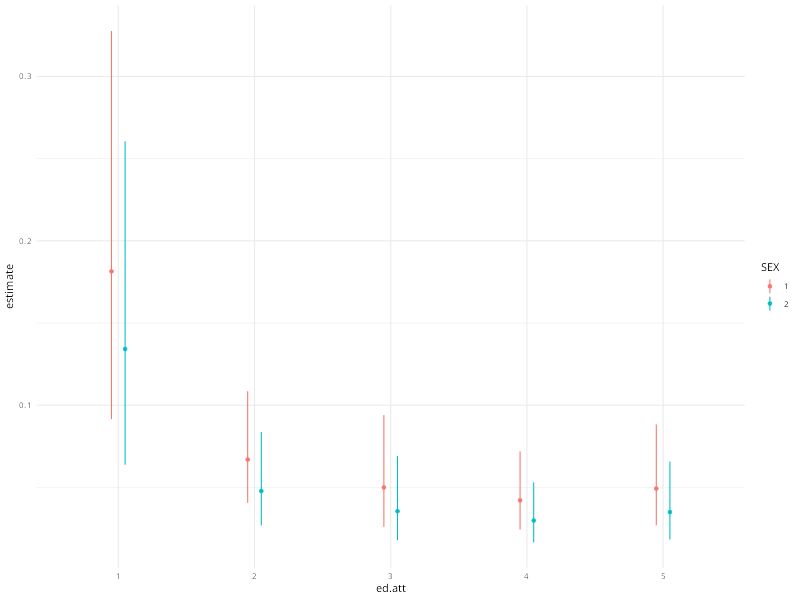

In [79]:
mn.age <- mean(asec25nj.rec$AGE, na.rm = TRUE) 

preds <- predictions(logit,
            condition = "ed.att", 
            newdata = datagrid(
              ed.att = 1:5,
              AGE = mn.age,
              SEX = c(1,2)
            )
          ) 
preds 

# graph the predictions
ggplot(
  data = preds,
  mapping = aes(
                x = ed.att,
                y = estimate,
                group = SEX,
                color = SEX
                )
  ) +
    geom_point(
      position = position_dodge(width = .2)) +
    geom_linerange(
      aes(
        ymin = conf.low,
        ymax = conf.high,
        ),
      position = position_dodge(width = .2)
  ) +
  theme_minimal()
    